In [1]:
# =============================================================================
# Invert elevation reconstruction -- multi-network entry point
# -----------------------------------------------------------------------------
# Single, city-parameterised notebook: it detects and corrects anomalous
# recorded invert (bottom) elevations and predicts missing ones, reusing the
# local spatial interpolation framework of rimElevation.ipynb, augmented with
# two physical-plausibility constraints -- depth (linked to the corrected rim
# elevation) and slope (linked to topological neighbours), as described in
# manuscript Section 2.4.
#
# On Angers, Kapiti Coast and Auckland, missing values are spatially well
# distributed, so this constrained spatial interpolation (Method 1) both
# corrects anomalies and predicts missing values. On Montpellier, missing
# invert elevations are concentrated in the city centre, where spatial
# interpolation has no known neighbour to work from; a complementary
# topological-traversal method (Method 2, Section 2.4.2) is used there
# instead, propagating known values along the pipe network.
#
# The network is selected via the `choice` variable in the next cell; all
# reconstruction logic lives in the shared `function.py` module, imported
# below. Requires df_pipe/df_node already carrying a corrected rim elevation
# (i.e. the output of rimElevation.ipynb).
# =============================================================================
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import geopandas as gpd
import networkx as nx
import matplotlib.colors as mcolors
import contextily as ctx
import random
import function
import importlib
from joblib import Parallel, delayed
from itertools import product

importlib.reload(function)

from function import *

In [2]:
# ── Network selection ──────────────────────────────────────────────────────
# Set `choice` to one of: "montpellier", "angers", "kapiti", "auckland".
# Each branch loads that network's preprocessed pipe/node tables and sets the
# projected CRS (`epsg`), the injected-anomaly amplitude upper bound
# (`err_max`, calibrated to the network's elevation range), the output name
# stem (`network`).
choice = "montpellier"

if choice == "angers":
    #Angers
    network = "Angers"
    epsg = "EPSG:2154"
    err_max = 80

elif choice == "kapiti":
    #Kapiti Coast
    network = "Kapiti"
    epsg = "EPSG:2193"
    err_max = 90

elif choice == "auckland":
    #Auckland
    network = "Auckland"
    epsg = "EPSG:2193"
    err_max = 100

elif choice == "montpellier":
    #Montpellier
    network = "Montpellier"
    epsg = "EPSG:2154"
    err_max = 120

df_pipe = pd.read_pickle(f"../data/{network}/df_pipe_{network}_rim.pkl")
df_node = pd.read_pickle(f"../data/{network}/df_node_{network}_rim.pkl")

In [3]:
# Minimal working table for invert-elevation reconstruction: node identifier,
# projected coordinates, and both elevation attributes -- the corrected rim
# elevation (used by the depth constraint) and the invert elevation to be
# reconstructed.
df_elev = df_node[["node_id", "x", "y", "rimElevation", "invertElevation"]]

In [4]:
# ── Directed topology graph (Montpellier only) ─────────────────────────────
# Built once from the pre-correction rim/invert elevations, for the slope
# constraint of Method 1 (Section 2.4.1) and the initial slope diagnostics
# below. Only Montpellier has a reconstructed topology (initial_node /
# terminal_node), so `G` stays None for the other three networks -- passed
# through untouched wherever the shared functions expect a graph argument.
G = None

if network == "Montpellier":
    G = nx.DiGraph()
    
    for _, node in df_elev.iterrows():
        G.add_node(
            node["node_id"],
            x = node["x"],
            y = node["y"],
            invertElevation = node["invertElevation"],
            rimElevation = node["rimElevation"]
        )
    
    for _, pipe in df_pipe.iterrows():
        if pd.notna(pipe["initial_node"]) and pd.notna(pipe["terminal_node"]):
            G.add_edge(
                pipe["initial_node"],
                pipe["terminal_node"],
                pipe_id = pipe["pipe_id"],
                length = pipe["length"]
            )

In [5]:
# ── Slope diagnostics on the raw (pre-correction) data (Montpellier only) ──
# Empirical distribution of pipe slopes computed directly from the recorded
# invert elevations, before any correction or prediction. Used to compare
# with the network after corrections and predictions.
if network == "Montpellier":
    slopes = slopeCalcul(G)
    slopes = np.array(slopes) * 100
    
    print(f"Slope 1e pct     : {np.quantile(slopes,0.01):.1f} %")
    print(f"Slope 5e pct     : {np.quantile(slopes,0.05):.1f} %")
    print(f"Slope median     : {np.quantile(slopes,0.5): .1f} %")
    print(f"Slope 99e pct     : {np.quantile(slopes,0.99):.1f} %")
    print(f"Slope 99.9e pct   : {np.quantile(slopes,0.999):.1f} %")
    
    print("Number of slopes below 0% : ",len(slopes[slopes < 0]))
    print("Number of slopes below -1% : ",len(slopes[slopes < -1]))
    print("Number of slopes below -5% : ",len(slopes[slopes < -5]))
    print("Number of slopes below -10% : ",len(slopes[slopes < -10]))
    print("Number of slopes : ",len(slopes))


Slope 1e pct     : -3.6 %
Slope 5e pct     : 0.0 %
Slope median     :  1.3 %
Slope 99e pct     : 16.8 %
Slope 99.9e pct   : 59.8 %
Number of slopes below 0% :  621
Number of slopes below -1% :  361
Number of slopes below -5% :  120
Number of slopes below -10% :  63
Number of slopes :  16798


Number of known :  17434
Number of unknown :  33188
Percentage of unknown :  0.6556042827229268


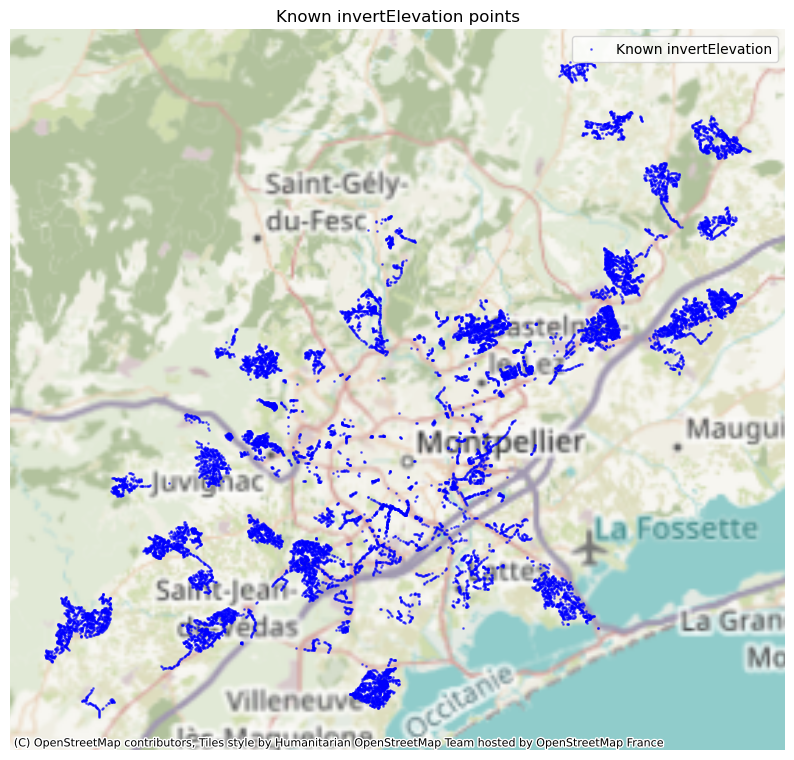

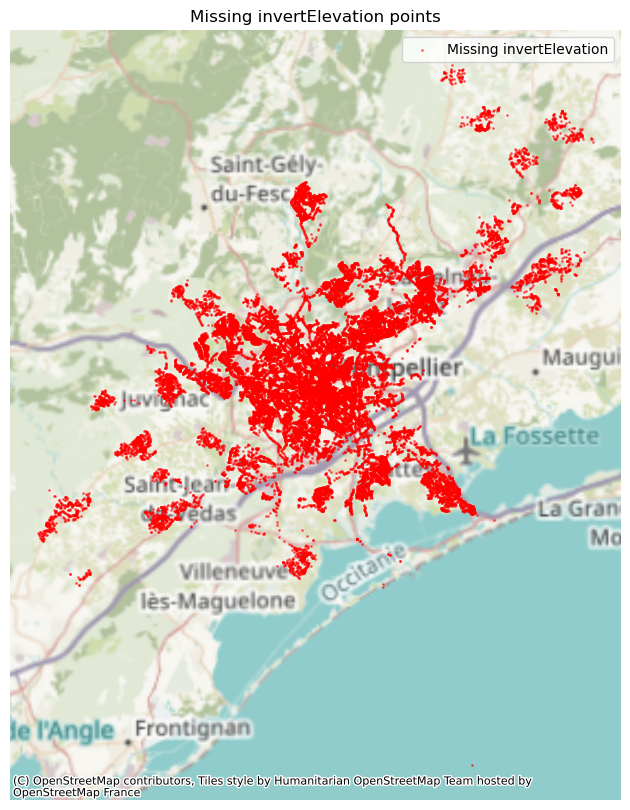

In [6]:
# ── Spatial distribution of known vs. missing invert elevation ─────────────
# Reproduces Figures of the manuscript (Section 2.4): mapping the known
# and missing invertElevation nodes shows whether the missing values are
# spatially scattered (Angers, Kapiti Coast, Auckland -- handled by Method 1's
# spatial interpolation) or concentrated in a specific area such as a city
# centre (Montpellier -- requiring the topological Method 2 instead).
known = df_elev.dropna(subset=["invertElevation"]).copy()
unknown = df_elev[df_elev["invertElevation"].isna()].copy()
print("Number of known : ", len(known))
print("Number of unknown : ", len(unknown))
print("Percentage of unknown : ", len(unknown) / (len(unknown) + len(known)))

# Transformer les DataFrames en GeoDataFrames
gdf_known = gpd.GeoDataFrame(known, geometry=gpd.points_from_xy(known["x"], known["y"]), crs=epsg)

gdf_unknown = gpd.GeoDataFrame(unknown, geometry=gpd.points_from_xy(unknown["x"], unknown["y"]), crs=epsg)

fig, ax = plt.subplots(figsize=(10, 10))

gdf_known.plot(ax=ax, markersize=1, alpha=0.5, color="blue",label="Known invertElevation")

ctx.add_basemap(ax, crs=gdf_known.crs, zoom=10)

ax.set_title("Known invertElevation points")
ax.set_axis_off()
ax.legend()
plt.show()

fig, ax = plt.subplots(figsize=(10, 10))

gdf_unknown.plot(ax=ax, markersize=1, alpha=0.5, color="red", label="Missing invertElevation")

ctx.add_basemap(ax, crs=gdf_known.crs, zoom=10)

ax.set_title("Missing invertElevation points")
ax.set_axis_off()
ax.legend()
plt.show()

In [7]:
# Empirical 1st/99th percentile of node depth (rim minus invert), used to
# sanity-check the plausible range before choosing the depth-constraint
# bounds explored in the grid search below.
print("1 percentile = ", df_node["depth"].quantile(0.01))
print("99 percentile = ", df_node["depth"].quantile(0.99))

1 percentile =  0.47000000000000597
99 percentile =  4.618499999999989


In [8]:
# ── Empirical medians used to centre the physical constraints ──────────────
# `depth_median`: median rim-minus-invert depth, computed for this network,
# used to centre the depth constraint (Section 2.4.1, Table 8 in the
# manuscript). `slope_median`: median pipe slope, computed from the topology
# and only meaningful for Montpellier, used to centre the slope constraint.
slope_median = 0
if network == "Montpellier":
    slopes = slopeCalcul(G)
    slope_median = np.quantile(slopes,0.5)

depth_median = df_node["depth"].quantile(0.5)
print(f"depth median = {depth_median:.3}")

depth median = 1.51


In [13]:
# ── invertElevation grid search: hyperparameter exploration (Method 1) ─────
# Same structure as the rimElevation grid search: one job per (spatial
# config × constraint config) pair, parallelised with joblib. Four families
# of constraint configurations are explored (Section 2.4.4): no constraint;
# depth constraint only (all four networks); slope constraint only; and both
# combined (Montpellier only, since the slope constraint needs a reconstructed
# topology that is unavailable for the other three networks).

def run_one_invert(method, radius, node_min, weight, cfg, df_elev, G, err_max):
    """Run modelWithInjectedErrors for one (spatial config, constraint
    config) pair and return its evaluation summary (empty list on failure)."""
    try:
        result = modelWithInjectedErrors(
            df_elev, radius, node_min, method, weight,
            seuil_clean=5, thresholds=thresholds, inter_threshold=inter_threshold,
            err_min=0, err_max=err_max, pourcent=0.1,
            feature="invertElevation", G=G,
            restriRim=cfg["restriRim"], restriInvert=cfg["restriInvert"],
            depth_min=cfg["depth_min"], depth_max=cfg["depth_max"],
            depth_median=cfg["depth_median"], alpha=cfg["alpha"],
            slope_min=cfg["slope_min"], slope_max=cfg["slope_max"],
            slope_median=cfg["slope_median"], pred_NaN=True, verbose=False
        )
        return result
    except Exception as e:
        print(f"ERROR: method={method} radius={radius} node_min={node_min} "
              f"weight={weight} cfg={cfg} → {e}")
        return []


# ── Parameters to vary ──────────────────────────────────────────────────
depth_configs = [
    (-2, 5),
    (-2, 8),
    (0, 5),
    (0, 8),
]

if network == "Montpellier":
    slope_configs = [
        (-0.05, 0.1),
        (-0.05, 0.2),
        (-0.1, 0.1),
        (-0.1, 0.2),
    ]
    slopes = slopeCalcul(G)
    slope_median_fixed = np.quantile(slopes, 0.5)
else:
    slope_configs = [(0, 0)]
    slope_median_fixed = 0

depth_median_fixed = df_node["depth"].quantile(0.5)
alpha_values = [0.3, 0.6, 0.9]

constraint_configs = []

# Case 1: no constraint
constraint_configs.append({
    "restriRim": False, "restriInvert": False,
    "depth_min": -9999, "depth_max": 9999, "depth_median": depth_median_fixed,
    "slope_min": -9999, "slope_max": 9999, "slope_median": slope_median_fixed,
    "alpha": 0,
})

# Case 2: restriRim only
for (dmin, dmax), alpha in product(depth_configs, alpha_values):
    constraint_configs.append({
        "restriRim": True, "restriInvert": False,
        "depth_min": dmin, "depth_max": dmax, "depth_median": depth_median_fixed,
        "slope_min": -9999, "slope_max": 9999, "slope_median": slope_median_fixed,
        "alpha": alpha,
    })
    
if network == "Montpellier":
    # Case 3: restriInvert only
    for (pmin, pmax), alpha in product(slope_configs, alpha_values):
        constraint_configs.append({
            "restriRim": False, "restriInvert": True,
            "depth_min": -9999, "depth_max": 9999, "depth_median": depth_median_fixed,
            "slope_min": pmin, "slope_max": pmax, "slope_median": slope_median_fixed,
            "alpha": alpha,
        })
    
    # Case 4: restriRim + restriInvert
    for (dmin, dmax), (pmin, pmax), alpha in product(depth_configs, slope_configs, alpha_values):
        constraint_configs.append({
            "restriRim": True, "restriInvert": True,
            "depth_min": dmin, "depth_max": dmax, "depth_median": depth_median_fixed,
            "slope_min": pmin, "slope_max": pmax, "slope_median": slope_median_fixed,
            "alpha": alpha,
        })

print(f"Number of constraint configs: {len(constraint_configs)}")

# ── General parameters ──────────────────────────────────────────────────
methods = ["IDW", "LR", "QR"]
thresholds = [40, 25, 15, 10, 5, 3]
inter_threshold = [10, 5, 3]

method_config = {
    "IDW": {"radii": [80, 150, 250], "node_mins": [3, 6], "weights": ["inverse"]},
    "LR":  {"radii": [250, 400], "node_mins": [6, 10], "weights": ["normal", "inverse", "inverseSquared"]},
    "QR":  {"radii": [250, 400], "node_mins": [15, 20], "weights": ["normal", "inverse", "inverseSquared"]},
}

jobs = [
    (method, radius, node_min, weight, cfg)
    for method in methods
    for radius in method_config[method]["radii"]
    for node_min in method_config[method]["node_mins"]
    for weight in method_config[method]["weights"]
    for cfg in constraint_configs
]
print(f"Number of jobs: {len(jobs)}")

Number of constraint configs: 73
Number of jobs: 2190


In [4]:
# ── Full run ─────────────────────────────────────────────────────────────
# n_jobs: number of CPU cores to use in parallel -- adjust to your machine
# (e.g. n_jobs=-1 uses all available cores).
all_results = Parallel(n_jobs=16, verbose=10)(
    delayed(run_one_invert)(method, radius, node_min, weight, cfg, df_elev, G, err_max)
    for method, radius, node_min, weight, cfg in jobs
)

# ── Flatten and save ──────────────────────────────────────────────────────
results_invert = [r for sublist in all_results for r in sublist]
df_results_invert = pd.DataFrame(results_invert)
df_results_invert.to_csv(f"../results_invert/results_invert_{network}_XXXXXXXX.csv", index=False)  # NOTE: replace XXXXXXXX with the run date
print(f"Saved: {len(df_results_invert)} rows")

In [9]:
# ── Manual single-configuration test (Method 1) ────────────────────────────
# Pick any hyperparameter combination by hand to quickly try it out independently of the systematic grid
# search above. Output is displayed, not stored.
modelWithInjectedErrors(df_elev, 400, 6, "LR", "inverseSquared", seuil_clean = 5, thresholds = [40, 25, 15, 10, 5],
                            inter_threshold = [5], err_min = 0, err_max = err_max, pourcent = 0.1,
                            feature = "invertElevation", G = G, restriRim = True, restriInvert = True,
                            depth_min = -2, depth_max = 8, depth_median = depth_median, alpha = 0.9,
                            slope_min = -0.1, slope_max = 0.2, slope_median = slope_median, pred_NaN = True)


Anomalous nodes identified and removed:  652
Anomalous nodes identified:  2421
Anomalous nodes corrected:  1538
Anomalous nodes identified:  2211
Anomalous nodes corrected:  1314
Anomalous nodes identified:  1952
Anomalous nodes corrected:  1142
Anomalous nodes identified:  1454
Anomalous nodes corrected:  794
Anomalous nodes identified:  1607
Anomalous nodes corrected:  1037
Corrected nodes  : 22927
Missing nodes remaining : 15103
Missing nodes reconstructed : 17393
Percentage of missing nodes reconstructed : 53.52%

Threshold =  5
Radius =  400
Min. neighbours required for a correction =  6
Injected errors range :  0  -  120
Model :  LR
── Distribution of the corrections ──
  Mean delta  : 32.1m
  Median delta: 27.2m
  Max delta   : 131.6m
 Median number of neighbours : 51.0

── Ten largest corrections ──
               node_id  original  corrected   delta  n_voisins
316   ass_rega_0020522       4.0     135.65  131.65        116
762   ass_rega_0043854     119.0       0.26  118.74    

[{'method': 'LR',
  'radius': 400,
  'seuil': 5,
  'node_min': 6,
  'weight_method': 'inverseSquared',
  'err_min': 0,
  'err_max': 120,
  'pct_error': 0.1,
  'feature': 'invertElevation',
  'restriRim': True,
  'restriInvert': True,
  'depth_min': -2,
  'depth_max': 8,
  'depth_median': np.float64(1.509999999999998),
  'slope_min': -0.1,
  'slope_max': 0.2,
  'slope_median': np.float64(0.013420521260628798),
  'alpha': 0.9,
  'n_aberrants_detected': 6104,
  'n_corrected': 22927,
  'n_nan_remaining': 15103,
  'n_nan_corrected': 17393,
  'pct_nan_corrected': 0.5352351058591827,
  'precision': 0.770478374836173,
  'recall': 0.9453266331658291,
  'f1': 0.8489935914793754,
  'matthews_corrcoef': 0.8357890921413076,
  'precision_rim_restr': 0.8035005413208228,
  'recall_rim_restr': 0.8950753768844221,
  'f1_rim_restr': 0.8468194352001521,
  'matthews_corrcoef_rim_restr': 0.830279144735436,
  'precision_inv_restr': 0.7943974630021141,
  'recall_inv_restr': 0.9063316582914572,
  'f1_inv_restr

In [10]:
# ── Final run: retained configuration per network (Method 1) ───────────────
# Apply each network's own best correction configuration. Angers, Kapiti Coast and Auckland
# additionally predict the genuinely missing values in the same run
# (`predictNaN`, Method 1); Montpellier's missing values are left untouched
# here and reconstructed separately by the topological Method 2 below
# (Section 2.4.2), since spatial interpolation alone cannot reach the city
# centre where they are concentrated.
X = df_elev.copy()
pred_rows=[]

if network == "Angers":
    thresholds = [40, 25, 15, 10, 5]
    radius = 250
    node_min = 15
    method = "QR"
    weight = "inverseSquared"
    depth = [0, 5]
    alpha = 0.9
    slope = [0, 0]
    restriRim = True
    restriInvert = False

if network == "Kapiti":
    thresholds = [40, 25, 15, 10, 5]
    radius = 400
    node_min = 20
    method = "QR"
    weight = "inverseSquared"
    depth = [-2, 8]
    alpha = 0.9
    slope = [0, 0]
    restriRim = True
    restriInvert = False

if network == "Auckland":
    thresholds = [40, 25, 15, 10, 5]
    radius = 400
    node_min = 15
    method = "QR"
    weight = "inverseSquared"
    depth = [-2, 8]
    alpha = 0.9
    slope = [0, 0]
    restriRim = True
    restriInvert = False

if network == "Montpellier":
    thresholds = [40, 25, 15, 10, 5]
    radius = 400
    node_min = 6
    method = "LR"
    weight = "inverseSquared"
    depth = [-2, 8]
    alpha = 0.9
    slope = [-0.1, 0.2]
    restriRim = True
    restriInvert = True

for threshold in thresholds:
    X, pred_rows = detect_and_correct(X, radius, threshold, node_min, method, G, weight, pred_rows, "invertElevation",
                        restriRim, restriInvert, depth[0], depth[1], depth_median, alpha, slope[0], slope[1], slope_median, verbose = True)
if network != "Montpellier":
    X, pred_rows = predictNaN(X, radius, node_min, method, weight, pred_rows, "invertElevation", G,
                restriRim, restriInvert, depth[0], depth[1], depth_median, alpha, slope[0], slope[1], slope_median)

Anomalous nodes identified:  12
Anomalous nodes corrected:  6
Anomalous nodes identified:  21
Anomalous nodes corrected:  16
Anomalous nodes identified:  14
Anomalous nodes corrected:  8
Anomalous nodes identified:  29
Anomalous nodes corrected:  7
Anomalous nodes identified:  198
Anomalous nodes corrected:  67


In [11]:
# ─── Merge the reconstructed invert elevation back into the tables ────────────
# df_elev/X share df_node's row order (no filtering happens in between), so
# the reconstructed invert elevation can be written straight back by position;
# the assertion guards that alignment assumption. df_pipe carries the same
# value on its endpoint nodes via a many-to-one merge (a node feeds several
# pipes), then the endpoint depths are recomputed.

# ─── 1. Alignment guard ────────────────────────────────────────────────────
assert X["node_id"].equals(df_node["node_id"]), "X and df_node have diverged — row alignment assumption broken"

# ─── 2. Update df_node ──────────────────────────────────────────────────
df_node["invertElevation"] = X["invertElevation"]

if network == "Montpellier":
    # ─── 3. Update df_pipe (initInvertElevation) ──────────────────────────────
    df_pipe = df_pipe.merge(
        df_node[["node_id", "invertElevation"]].rename(
            columns={"node_id": "initial_node", "invertElevation": "init_invert_new"}),
        on="initial_node",
        how="left"
    )
    df_pipe["initInvertElevation"] = df_pipe["init_invert_new"].combine_first(df_pipe["initInvertElevation"])
    df_pipe = df_pipe.drop(columns=["init_invert_new"])
    
    # ─── 4. Update df_pipe (terminalInvertElevation) ──────────────────────────
    df_pipe = df_pipe.merge(
        df_node[["node_id", "invertElevation"]].rename(
            columns={"node_id": "terminal_node", "invertElevation": "term_invert_new"}),
        on="terminal_node",
        how="left"
    )
    df_pipe["terminalInvertElevation"] = df_pipe["term_invert_new"].combine_first(df_pipe["terminalInvertElevation"])
    df_pipe = df_pipe.drop(columns=["term_invert_new"])

    # ─── 5. Recompute the derived depth variables ──────────────────────────
    df_pipe["initDepth"] = df_pipe["initRimElevation"] - df_pipe["initInvertElevation"]
    df_pipe["terminalDepth"] = df_pipe["terminalRimElevation"] - df_pipe["terminalInvertElevation"]
    df_pipe["slope"] = (
        (df_pipe["initInvertElevation"] - df_pipe["terminalInvertElevation"]) / df_pipe["length"] * 100
    )

df_node["depth"] = df_node["rimElevation"] - df_node["invertElevation"]


In [12]:
# ── Rebuild the topology graph with the Method-1 results (Montpellier) ─────
# Same construction as the earlier graph (cell 3), but from df_node/df_pipe
# now carrying Method 1's corrected invert elevation. This refreshed graph is
# the starting point for the topological Method 2 (Section 2.4.2): the
# upstream/downstream traversal reads its `invertElevation` node attributes.
if network == "Montpellier":
    G = nx.DiGraph()
    
    for _, node in df_node.iterrows():
        G.add_node(
            node["node_id"],
            x = node["x"],
            y = node["y"],
            invertElevation = node["invertElevation"],
            rimElevation = node["rimElevation"]
        )
    
    for _, pipe in df_pipe.iterrows():
        if pd.notna(pipe["initial_node"]) and pd.notna(pipe["terminal_node"]):
            G.add_edge(
                pipe["initial_node"],
                pipe["terminal_node"],
                pipe_id = pipe["pipe_id"],
                length = pipe["length"]
            )

In [13]:
# ── Method 2 grid search: hyperparameter exploration (Montpellier only) ────
# Validates the topological-traversal prediction (Section 2.4.2) by masking:
# for each hyperparameter configuration, 10% of the known invert elevations
# are hidden (`hide_invert`), predicted back from the remaining topology
# (`invert_prediction`), and compared against the held-out truth
# (`invert_result`). Each configuration is averaged over 5 random masking
# seeds to stabilise the estimate (Section 2.4.4, "Prediction phase"). Two
# families of configurations are compared: with the depth constraint active
# (`const=True`, varying its bounds and the correction amplitude alpha) and
# without any constraint (`const=False`).
if network == "Montpellier":
    def run_one_pred_topo(dmin, dmax, a, const, G, seeds, depth_median):
        err_list = []
        pctNbCorr_list = []
        pct_nodes_still_nan_list = []
        results = []
        try:
            for seed in seeds:
                (G_test, verif) = hide_invert(G, pourcent = 0.1, seed = seed)
                G_predict = invert_prediction(G_test , depth_min = dmin, depth_max = dmax, alpha = a, restriRim = const)
                (err_abs, pctNbCorr, pct_nodes_still_nan) = invert_result(G_predict, verif)
                err_list.append(err_abs)
                pctNbCorr_list.append(pctNbCorr)
                pct_nodes_still_nan_list.append(pct_nodes_still_nan)
            summary = {
                "abs_err" : sum(err_list) / len(err_list),
                "pctNbCorr" : sum(pctNbCorr_list) / len(pctNbCorr_list),
                "pct_nodes_still_nan" : sum(pct_nodes_still_nan_list) / len(pct_nodes_still_nan_list),
                "restriRim" : const,
                "depth_min" : dmin,
                "depth_max" : dmax,
                "depth_median" : depth_median,
                "alpha" : a,
                    }
            results.append(summary)
        except Exception as e:
            print(f"ERROR : {e}")
        return results
    
    depths_min = [-5, -2, 0]
    depths_max = [5, 8, 10]
    alphas = [0.3, 0.6, 0.9]
    constraint = [True, False]
    
    jobs = []
    for const in constraint:
        if const == False:
            depth_min = [0]
            depth_max = [0]
            alpha = [0]
        else:
            depth_min = depths_min
            depth_max = depths_max
            alpha = alphas
        for dmin in depth_min:
            for dmax in depth_max:
                for a in alpha:
                    jobs.append((dmin, dmax, a, const))
    
    seeds = [1, 10, 42, 250, 400]
    depth_median = df_node["depth"].quantile(0.5)
    
    print(f"Number of jobs: {len(jobs)}")

Number of jobs: 28


In [76]:
if network == "Montpellier":
    # ── Full run ─────────────────────────────────────
    # n_jobs: number of CPU cores to use in parallel -- adjust to your machine
    # (e.g. n_jobs=-1 uses all available cores).
    all_results = Parallel(n_jobs=16, verbose=10)(
        delayed(run_one_pred_topo)(dmin, dmax, a, const, G, seeds, depth_median)
        for dmin, dmax, a, const in jobs
    )
    
    # ── Flatten and save ──────────────────────────────
    results = [r for sublist in all_results for r in sublist]
    df_results = pd.DataFrame(results)
    df_results.to_csv(f"../results_invert/results_invert_{network}_predTopo_after_correction_XXXXXXXX.csv", index=False) # NOTE: replace XXXXXXXX with the run date before executing
    print(f"Saved: {len(df_results)} rows")

[Parallel(n_jobs=16)]: Using backend LokyBackend with 16 concurrent workers.
[Parallel(n_jobs=16)]: Done   3 out of  28 | elapsed:  2.5min remaining: 20.6min
[Parallel(n_jobs=16)]: Done   6 out of  28 | elapsed:  2.5min remaining:  9.2min
[Parallel(n_jobs=16)]: Done   9 out of  28 | elapsed:  2.5min remaining:  5.4min
[Parallel(n_jobs=16)]: Done  12 out of  28 | elapsed:  2.7min remaining:  3.6min
[Parallel(n_jobs=16)]: Done  15 out of  28 | elapsed:  2.7min remaining:  2.3min
[Parallel(n_jobs=16)]: Done  18 out of  28 | elapsed:  4.0min remaining:  2.2min
[Parallel(n_jobs=16)]: Done  21 out of  28 | elapsed:  4.1min remaining:  1.4min
[Parallel(n_jobs=16)]: Done  24 out of  28 | elapsed:  4.1min remaining:   41.3s


Saved: 28 rows


[Parallel(n_jobs=16)]: Done  28 out of  28 | elapsed:  4.2min finished


In [14]:
# ── Final Method-2 prediction pass (Montpellier) ────────────────────────────
# Grid-search finding (cells 14-15): the unconstrained model (restriRim=False)
# performs best overall. This leaves ~8% of the nodes without an invert elevation.
# `verif` is intentionally empty: unlike the grid search above, this is the
# real prediction run (no masking), so there is no held-out truth to score
# `invert_result` against -- only its printed coverage figures are
# informative here.
if network == "Montpellier":
    depth_median = df_node["depth"].quantile(0.5)
    G_predict = G.copy()
    verif = []

    G_predict = invert_prediction(G_predict, depth_min = 0, depth_max = 0, depth_median = depth_median, alpha = 0, restriRim=False)
    invert_result(G_predict, verif, verbose = True)


Mean absolute error :  None
Percentage of masked nodes recovered :  None
Percentage of network nodes still missing :  8.587940590544193


In [15]:
# ── Slope diagnostics after Method-2 prediction (Montpellier) ──────────────
# Same computation as the pre-correction diagnostics (cell 4), now run on
# `G_predict` to check the hydraulic plausibility of the completed network
# (manuscript Section 3.2.3, "Hydraulic consistency of the slopes").
if network == "Montpellier":
    slopes = slopeCalcul(G_predict)
    slopes = np.array(slopes) * 100
    
    print(f"Slope 1e pct     : {np.quantile(slopes,0.01):.1f} %")
    print(f"Slope 5e pct     : {np.quantile(slopes,0.05):.1f} %")
    print(f"Slope median     : {np.quantile(slopes,0.5): .1f} %")
    print(f"Slope 99e pct     : {np.quantile(slopes,0.99):.1f} %")
    print(f"Slope 99.9e pct   : {np.quantile(slopes,0.999):.1f} %")
    
    print("Number of slopes below 0% : ",len(slopes[slopes < 0]))
    print("Number of slopes below -1% : ",len(slopes[slopes < -1]))
    print("Number of slopes below -5% : ",len(slopes[slopes < -5]))
    print("Number of slopes below -10% : ",len(slopes[slopes < -10]))
    print("Number of slopes : ",len(slopes))

Slope 1e pct     : -382.2 %
Slope 5e pct     : -1.2 %
Slope median     :  16.7 %
Slope 99e pct     : 460.3 %
Slope 99.9e pct   : 2764.0 %
Number of slopes below 0% :  2773
Number of slopes below -1% :  2260
Number of slopes below -5% :  1805
Number of slopes below -10% :  1660
Number of slopes :  44303


In [16]:
# ─── Merge the Method-2-predicted invert elevation back into the tables ───
# (Montpellier only) Mirrors the merge-back logic used after Method 1
# (cell 12), but reading the predicted values from the graph `G` instead of
# from a DataFrame, since Method 2 operates directly on the NetworkX graph.
if network == "Montpellier":
    G = G_predict.copy()
    # ─── 1. Retrieve the invertElevation values from the graph ──────────────────
    invert_from_graph = pd.DataFrame([
        {
            "node_id": node_id,
            "invert_new": data.get("invertElevation")
        }
        for node_id, data in G.nodes(data=True)
    ])
    
    # Keep only the known (non-null) values
    invert_from_graph["invert_new"] = pd.to_numeric(
        invert_from_graph["invert_new"],
        errors="coerce"
    )
    
    invert_from_graph = invert_from_graph.dropna(subset=["invert_new"])
    
    # Safety net in case of duplicate node ids
    invert_from_graph = invert_from_graph.drop_duplicates(
        subset="node_id",
        keep="last"
    )
    
    # ─── 2. Update df_node without losing its other columns ────────────────────
    df_node = df_node.merge(
        invert_from_graph,
        on="node_id",
        how="left"
    )
    
    df_node["invertElevation"] = df_node["invert_new"].combine_first(
        df_node["invertElevation"]
    )
    df_node = df_node.drop(columns=["invert_new"])
    
    # ─── 3. Update initInvertElevation in df_pipe ───────────────────────────────
    df_pipe = df_pipe.merge(
        invert_from_graph.rename(columns={
            "node_id": "initial_node",
            "invert_new": "init_invert_new"
        }),
        on="initial_node",
        how="left"
    )
    
    df_pipe["initInvertElevation"] = df_pipe["init_invert_new"].combine_first(
        df_pipe["initInvertElevation"]
    )
    df_pipe = df_pipe.drop(columns=["init_invert_new"])
    
    # ─── 4. Update terminalInvertElevation in df_pipe ───────────────────────────
    df_pipe = df_pipe.merge(
        invert_from_graph.rename(columns={
            "node_id": "terminal_node",
            "invert_new": "term_invert_new"
        }),
        on="terminal_node",
        how="left"
    )
    
    df_pipe["terminalInvertElevation"] = df_pipe["term_invert_new"].combine_first(
        df_pipe["terminalInvertElevation"]
    )
    df_pipe = df_pipe.drop(columns=["term_invert_new"])
    
    # ─── 5. Recompute the derived variables ─────────────────────────────────────
    df_node["depth"] = df_node["rimElevation"] - df_node["invertElevation"]
    df_pipe["initDepth"] = (
        df_pipe["initRimElevation"] - df_pipe["initInvertElevation"]
    )
    df_pipe["terminalDepth"] = (
        df_pipe["terminalRimElevation"] - df_pipe["terminalInvertElevation"]
    )    
    df_pipe["slope"] = (
        (df_pipe["initInvertElevation"] - df_pipe["terminalInvertElevation"])
        / df_pipe["length"] * 100
    )

In [17]:
# ── Serialisation ───────────────────────────────────────────────────────
# Save the updated pipe and node tables (invert elevation corrected/
# completed) as the final output of the reconstruction pipeline for this
# network.
df_node.to_pickle(f"../data/{network}/df_node_{network}_invert.pkl")
df_pipe.to_pickle(f"../data/{network}/df_pipe_{network}_invert.pkl")